# Lab5 Henrik

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

In [47]:
url_r = 'data/winequality-red.csv'
url_w = 'data/winequality-white.csv'

df_r = pd.read_csv(url_r, sep=';')
df_w = pd.read_csv(url_w, sep=';')

df_r['IsRed'] = True
df_w['IsRed'] = False
whinequality = pd.concat([df_r, df_w], ignore_index=True)

In [48]:
whinequality.to_csv('data/whinequality.csv', index=False)

In [49]:
url = 'data/whinequality.csv'
df = pd.read_csv(url, sep=',')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,IsRed
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,True
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,True
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,True
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,True
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,True


In [50]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  IsRed                 6497 non-null   bool   
dtypes: bool(1), float64(11), int64(1)
memory usage: 615.6 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [51]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
IsRed                   0
dtype: int64

Text(0.5, 1.0, 'Wine quality greater than 7')

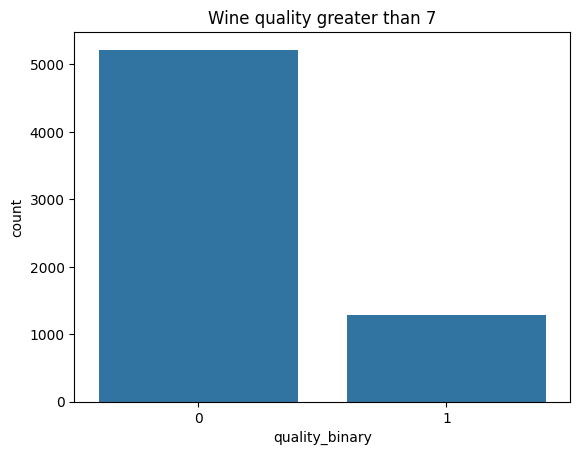

In [52]:
df['quality_binary'] = np.where(df['quality'] >= 7, 1, 0)
sns.countplot(data=df, x='quality_binary')
plt.title('Wine quality greater than 7')

In [53]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [54]:
X = df.drop(['quality', 'quality_binary'], axis=1)
y = df['quality_binary']

X.describe()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Before scaling:\n", X['pH'].head(10))
print("\nAfter scaling:\n", X_scaled_df['pH'].head(10))

Before scaling:
 0    3.51
1    3.20
2    3.26
3    3.16
4    3.51
5    3.51
6    3.30
7    3.39
8    3.36
9    3.35
Name: pH, dtype: float64

After scaling:
 0    1.813090
1   -0.115073
2    0.258120
3   -0.363868
4    1.813090
5    1.813090
6    0.506915
7    1.066704
8    0.880108
9    0.817909
Name: pH, dtype: float64


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [60]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(5, 31)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)
knn_gscv.fit(X_train, y_train)

optimal_k = knn_gscv.best_params_['n_neighbors']
print("Optimal K:", optimal_k)
print(knn_gscv.cv_results_['mean_test_score'])

Optimal K: 18
[0.82780304 0.83351975 0.83109975 0.83329755 0.82604093 0.82868216
 0.82714322 0.83242109 0.83264135 0.83330118 0.83044186 0.83440104
 0.83352096 0.835719   0.83571852 0.83505893 0.83351975 0.83154027
 0.82934126 0.82846142 0.82978034 0.83153979 0.83176006 0.83285944
 0.83175957 0.83175957]


In [61]:
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

y_pred = knn_optimal.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.8430769230769231
Confusion Matrix:
[[1503   82]
 [ 224  141]]


In [64]:
svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

accuracy_linear = accuracy_score(y_test, y_pred_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("Linear Kernel - accuracy: ", accuracy_linear)
print("Linear Kernel - Confusion Matrix:")
print(cm_linear)

print("RBF Kernel - accuracy:", accuracy_rbf)
print("RBF Kernel - Confusion Matrix")
print(cm_rbf)

Linear Kernel - accuracy:  0.8128205128205128
Linear Kernel - Confusion Matrix:
[[1585    0]
 [ 365    0]]
RBF Kernel - accuracy: 0.8358974358974359
RBF Kernel - Confusion Matrix
[[1531   54]
 [ 266   99]]


In [66]:
summary = {
    'Classifier': ['KNN', 'SVM (Linear Kernel)', 'SVM (RBF Kernel)'],
    'Accuracy': [accuracy, accuracy_linear, accuracy_rbf]
}
summary_df = pd.DataFrame(summary)
print(summary_df)

            Classifier  Accuracy
0                  KNN  0.843077
1  SVM (Linear Kernel)  0.812821
2     SVM (RBF Kernel)  0.835897


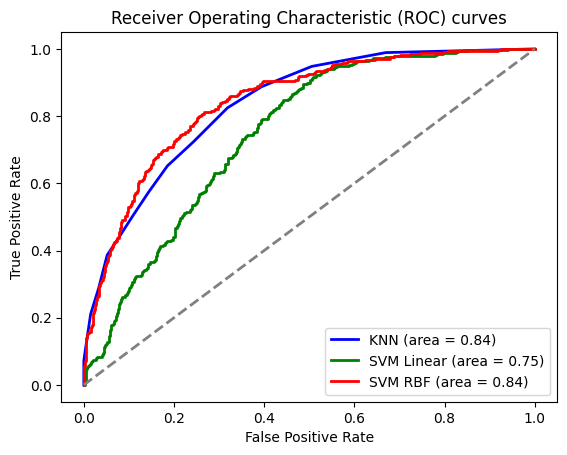

In [73]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_optimal.predict_proba(X_test)[:,1])
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_svm_linear, tpr_svm_linear, _ = roc_curve(y_test, svm_linear.decision_function(X_test))
roc_auc_svm_linear = auc(fpr_svm_linear, tpr_svm_linear)

fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test, svm_rbf.decision_function(X_test))
roc_auc_svm_rbf = auc(fpr_svm_rbf, tpr_svm_rbf)

plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label='KNN (area = %0.2f)' % roc_auc_knn)
plt.plot(fpr_svm_linear, tpr_svm_linear, color='green', lw=2, label='SVM Linear (area = %0.2f)' % roc_auc_svm_linear)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='red', lw=2, label='SVM RBF (area = %0.2f)' % roc_auc_svm_rbf)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

Text(0.5, 1.0, 'Correlation Matrix')

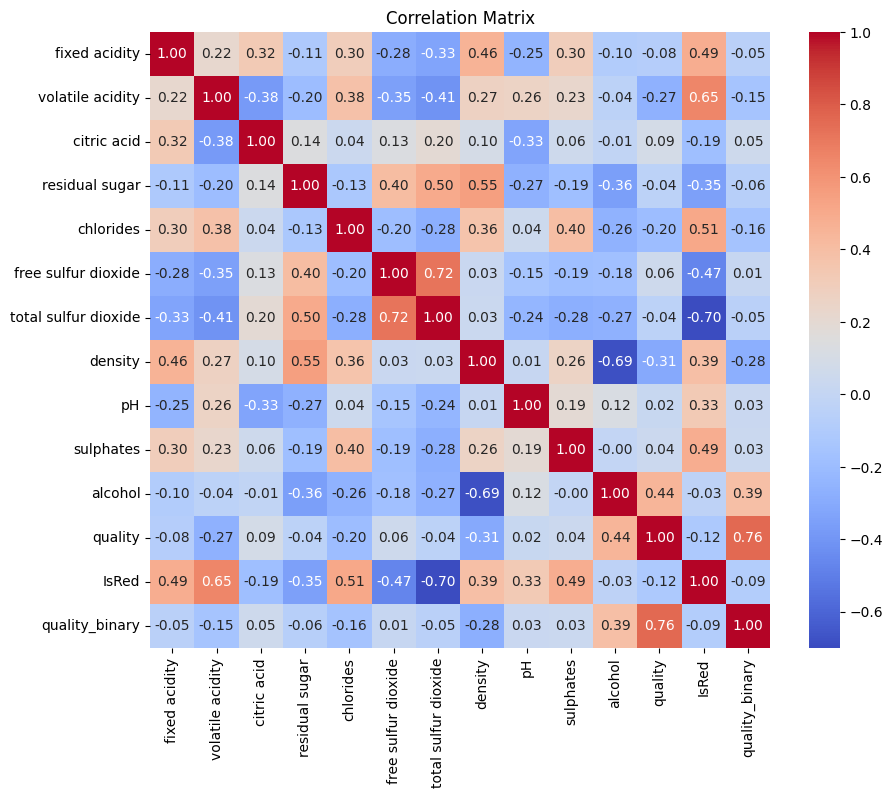

In [80]:
correlation_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')